In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("Sample Project1.xlsx")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.shape

(9994, 21)

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
df['Sales'].sum()

np.float64(2297200.8603)

In [12]:
df.groupby('Region')['Sales'].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

In [14]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

In [15]:
df[['Sales', 'Profit', 'Profit Margin']].head()

,Sales,Profit,Profit Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [16]:
df.groupby('Category')['Profit Margin'].mean()

Category
Furniture           3.878353
Office Supplies    13.803029
Technology         15.613805
Name: Profit Margin, dtype: float64

In [17]:
df.groupby('Discount')['Profit'].mean()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

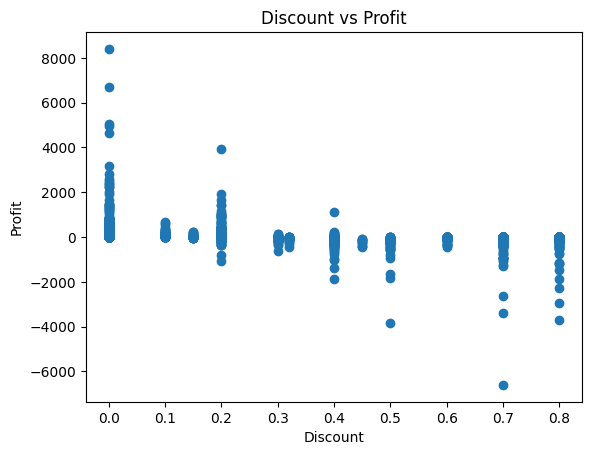

In [18]:
plt.scatter(df['Discount'], df['Profit'])

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()

In [19]:
loss_products = df[df['Profit'] < 0]

loss_products[['Product Name', 'Profit']].head()

,Product Name,Profit
3,Bretford CR4500 Series Slim Rectangular Table,-383.0310
14,Holmes Replacement Filter for HEPA Air Cleaner...,-123.8580
15,Storex DuraTech Recycled Plastic Frosted Binders,-3.8160
23,"Global Deluxe Stacking Chair, Gray",-1.0196
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",-1665.0522


In [20]:
loss_products.groupby('Product Name')['Profit'].sum().sort_values().head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
GBC DocuBind P400 Electric Binding System                                     -6859.3896
Lexmark MX611dhe Monochrome Laser Printer                                     -5269.9690
GBC Ibimaster 500 Manual ProClick Binding System                              -5098.5660
GBC DocuBind TL300 Electric Binding System                                    -4162.0336
Cubify CubeX 3D Printer Triple Head Print                                     -3839.9904
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind   -3431.6730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                      -3107.5272
Ibico EPK-21 Electric Binding System                                          -2929.4845
Bush Advantage Collection Racetrack Conference Table                          -2545.2600
Name: Profit, dtype: float64

In [21]:
df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

In [22]:
monthly_profit = df.groupby('Month')['Profit'].sum()

monthly_profit

KeyError: 'Month'

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [24]:
df['Month'] = df['Order Date'].dt.month

In [25]:
monthly_profit = df.groupby('Month')['Profit'].sum()

monthly_profit

Month
1     25167.1017
2     23753.6477
3     29336.5893
4     12267.1962
5     24234.4105
6     21164.9016
7     10008.6488
8     24820.3450
9     34554.8774
10    22336.9254
11    26435.0796
12    32317.2985
Name: Profit, dtype: float64

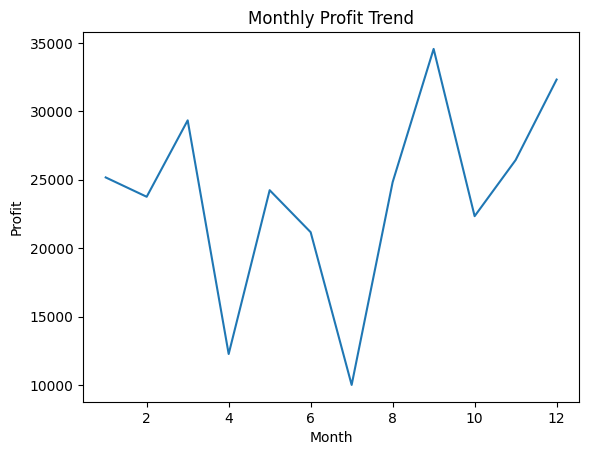

In [26]:
monthly_profit.plot(kind='line')

plt.title("Monthly Profit Trend")

plt.xlabel("Month")

plt.ylabel("Profit")

plt.show()

In [27]:
df[['Sales', 'Profit', 'Discount', 'Quantity']].corr()

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


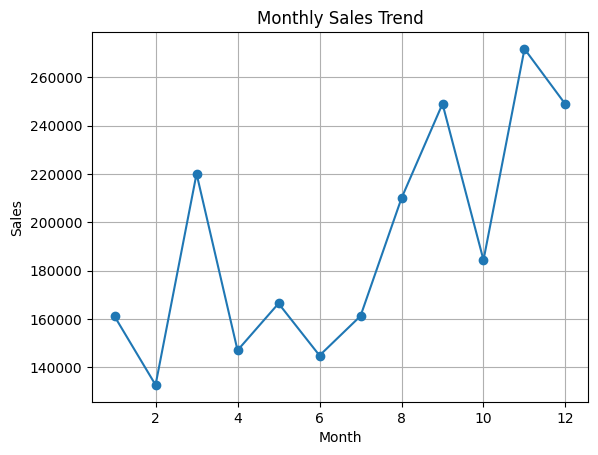

In [28]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

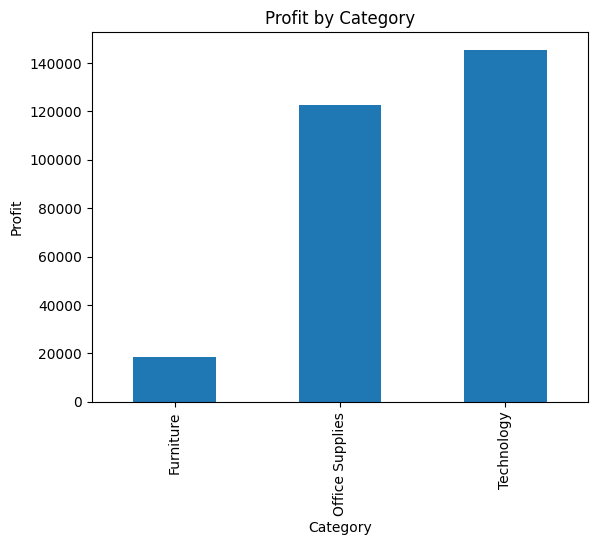

In [29]:
category_profit = df.groupby('Category')['Profit'].sum()

category_profit.plot(kind='bar')

plt.title("Profit by Category")

plt.xlabel("Category")

plt.ylabel("Profit")

plt.show()

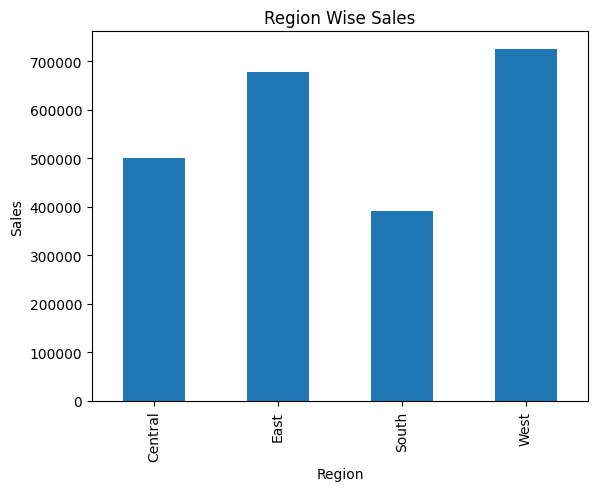

In [30]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')

plt.title("Region Wise Sales")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

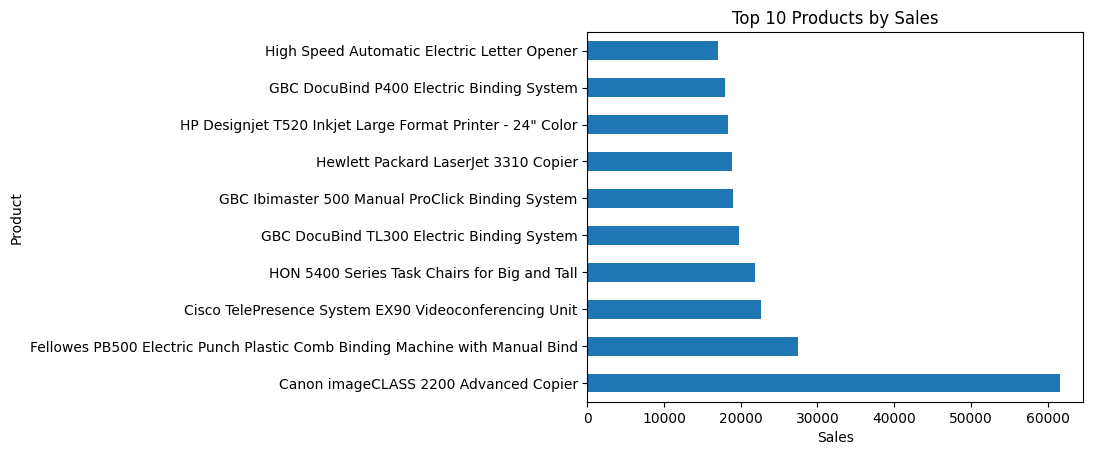

In [31]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')

plt.title("Top 10 Products by Sales")

plt.xlabel("Sales")

plt.ylabel("Product")

plt.show()

In [32]:
plt.savefig("monthly_sales.png")

<Figure size 640x480 with 0 Axes>

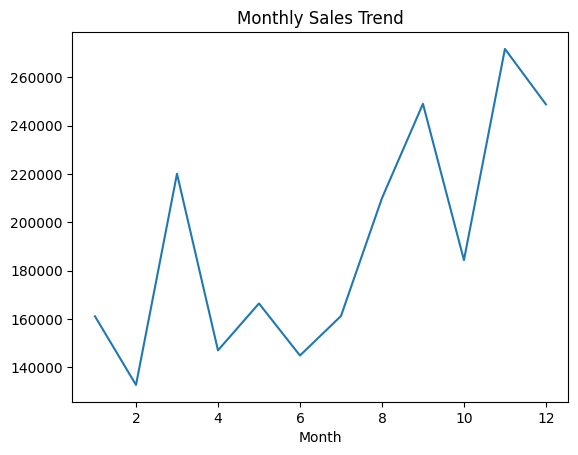

In [33]:
monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")

plt.savefig("monthly_sales.png")

plt.show()